In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="statsbombpy")

import pandas as pd
from statsbombpy import sb
from pathlib import Path

pd.set_option('display.max_columns', None)
RAW_DIR = Path("../data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
comps = sb.competitions()
comps[['competition_id', 'season_id', 'competition_name', 'season_name', 'match_available_360']]

,competition_id,season_id,competition_name,season_name,match_available_360
0,9,281,1. Bundesliga,2023/2024,2025-07-06T04:26:07.636270
1,9,27,1. Bundesliga,2015/2016,NaN
2,1267,107,African Cup of Nations,2023,NaN
3,16,4,Champions League,2018/2019,NaN
4,16,1,Champions League,2017/2018,NaN
...,...,...,...,...,...
70,35,75,UEFA Europa League,1988/1989,NaN
71,53,315,UEFA Women's Euro,2025,2025-07-29T16:03:07.355174
72,53,106,UEFA Women's Euro,2022,2024-02-13T13:30:52.820588
73,72,107,Women's World Cup,2023,2025-07-14T10:10:27.224586


In [3]:
comps_with_360 = comps[comps['match_available_360'].notna()]
comps_with_360[['competition_id', 'season_id', 'competition_name', 'season_name', 'match_available_360']]

,competition_id,season_id,competition_name,season_name,match_available_360
0,9,281,1. Bundesliga,2023/2024,2025-07-06T04:26:07.636270
29,43,106,FIFA World Cup,2022,2024-12-16T10:21:13.710934
38,11,90,La Liga,2020/2021,2025-01-29T18:09:18.620699
58,7,235,Ligue 1,2022/2023,2025-06-30T02:31:32.046070
59,7,108,Ligue 1,2021/2022,2025-06-15T13:02:45.341609
61,44,107,Major League Soccer,2023,2025-07-01T11:17:29.514495
68,55,282,UEFA Euro,2024,2025-03-24T14:12:30.785094
69,55,43,UEFA Euro,2020,2024-07-31T12:30:57.587087
71,53,315,UEFA Women's Euro,2025,2025-07-29T16:03:07.355174
72,53,106,UEFA Women's Euro,2022,2024-02-13T13:30:52.820588


In [4]:
TARGETS = [
    (55, 43),    # Euro 2020
    (55, 282),   # Euro 2024
]

all_matches = []
for comp_id, season_id in TARGETS:
    m = sb.matches(competition_id=comp_id, season_id=season_id)
    m['competition_id'] = comp_id
    m['season_id'] = season_id
    all_matches.append(m)
    print(f"Comp {comp_id}, Season {season_id}: {len(m)} matches")

matches = pd.concat(all_matches, ignore_index=True)
print(f"\nTotal matches: {len(matches)}")
matches[['match_id', 'competition_id', 'season_id', 'home_team', 'away_team', 'match_date']].head()

Comp 55, Season 43: 51 matches
Comp 55, Season 282: 51 matches

Total matches: 102


,match_id,competition_id,season_id,home_team,away_team,match_date
0,3795108,55,43,Switzerland,Spain,2021-07-02
1,3788769,55,43,Russia,Denmark,2021-06-21
2,3788766,55,43,Italy,Wales,2021-06-20
3,3795220,55,43,Italy,Spain,2021-07-06
4,3788761,55,43,Sweden,Slovakia,2021-06-18


In [5]:
test_match_id = matches.iloc[0]['match_id']
print(f"Testing with match_id={test_match_id}")

events = sb.events(match_id=test_match_id)
print(f"Events shape: {events.shape}")
print(f"Sample columns: {events.columns.tolist()[:15]}...")
events.head(3)

Testing with match_id=3795108


Events shape: (4990, 90)
Sample columns: ['50_50', 'ball_receipt_outcome', 'ball_recovery_offensive', 'ball_recovery_recovery_failure', 'block_deflection', 'block_offensive', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_right_foot', 'counterpress', 'dribble_outcome', 'dribble_overrun']...


,50_50,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_type,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2e4b1b7f-e67e-4bef-8cf1-2eab2ab81af2,1,NaN,NaN,3795108,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Switzerland,773,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Switzerland,773,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f73c3f38-8c45-4802-8cb9-5a87234f385b,2,NaN,NaN,3795108,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Switzerland,773,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Spain,772,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9098375d-3f07-4241-bdc9-3602a2e5c754,3,NaN,NaN,3795108,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Switzerland,773,[18099197-a92a-4398-ac5e-39dad539c3eb],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:00.000,Half Start,NaN


In [6]:
raw_frames = sb.frames(match_id=test_match_id, fmt="dict")

print(f"Number of 360 frames: {len(raw_frames)}")
print(f"Type: {type(raw_frames)}")
print(f"First element type: {type(raw_frames[0])}")

first_frame = raw_frames[0]
print(f"\nKeys in a frame: {list(first_frame.keys())}")
print(f"event_uuid: {first_frame['event_uuid']}")
print(f"n visible players: {len(first_frame['freeze_frame'])}")
print(f"\nFirst player:")
print(first_frame['freeze_frame'][0])

Number of 360 frames: 4220
Type: <class 'list'>
First element type: <class 'dict'>

Keys in a frame: ['event_uuid', 'visible_area', 'match_id', 'freeze_frame']
event_uuid: ea57ee78-a4ef-4d62-81c7-98cdf1c11925
n visible players: 20

First player:
{'teammate': True, 'actor': False, 'keeper': False, 'location': [35.47745334898371, 34.656207868611105]}


## M2 — Event/360 join + canonical event table

Build the open-play canonical table from `data/raw/`, persist it to `data/interim/`,
verify load time, and run a visual coordinate sanity check on one possession.

In [7]:
import time
from beyond_the_ball.data.join_360 import build_canonical_table, load_canonical_table

CANONICAL_PATH = "../data/interim/events_360_open_play.parquet"

t0 = time.perf_counter()
canonical = build_canonical_table(
    raw_dir="../data/raw",
    output_path=CANONICAL_PATH,
)
print(f"build seconds: {time.perf_counter() - t0:.2f}")
print(f"rows: {len(canonical):,}")
print(f"cols: {len(canonical.columns)}")
print(f"matches: {canonical['match_id'].nunique()}")
print(f"events with 360 frame: {canonical['freeze_frame'].notna().mean() * 100:.1f}%")

build seconds: 5.23
rows: 162,345
cols: 120
matches: 102
events with 360 frame: 88.1%


In [8]:
t0 = time.perf_counter()
loaded = load_canonical_table(CANONICAL_PATH)
load_s = time.perf_counter() - t0
print(f"load seconds: {load_s:.2f}  (target < 10s)")
assert load_s < 10, "Canonical parquet load is too slow"
loaded.head(3)

load seconds: 0.84  (target < 10s)


,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,event_uuid,match_id_360,visible_area,freeze_frame,n_visible_players,clearance_other,foul_committed_penalty,foul_committed_type,foul_won_penalty,injury_stoppage_in_chain,pass_cut_back,shot_aerial_won,block_offensive,dribble_no_touch,foul_committed_offensive,pass_straight,50_50,goalkeeper_success_in_play,pass_miscommunication,bad_behaviour_card,block_save_block,shot_open_goal,goalkeeper_lost_in_play,shot_one_on_one,goalkeeper_shot_saved_to_post,shot_saved_to_post,goalkeeper_shot_saved_off_target,shot_saved_off_target,shot_redirect,shot_follows_dribble,player_off_permanent,goalkeeper_penalty_saved_to_post
0,NaN,None,None,None,None,None,NaN,None,None,None,None,None,NaN,None,NaN,NaN,0.0,None,NaN,None,None,NaN,None,NaN,NaN,None,NaN,NaN,59645e89-9c7f-46f2-b662-332c5b8bba12,1,NaN,None,3788741,0,None,None,None,None,NaN,NaN,NaN,None,None,None,None,NaN,None,NaN,None,NaN,None,NaN,NaN,None,None,NaN,None,NaN,1,Regular Play,NaN,NaN,NaN,1,Turkey,909,None,0,NaN,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4141.0, 'lineup': [{'player': {'...",Turkey,909,00:00:00.000,Starting XI,None,59645e89-9c7f-46f2-b662-332c5b8bba12,NaN,None,None,NaN,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None
1,NaN,None,None,None,None,None,NaN,None,None,None,None,None,NaN,None,NaN,NaN,0.0,None,NaN,None,None,NaN,None,NaN,NaN,None,NaN,NaN,f063a4b6-f5ad-4576-b31d-a8dbe50f693e,2,NaN,None,3788741,0,None,None,None,None,NaN,NaN,NaN,None,None,None,None,NaN,None,NaN,None,NaN,None,NaN,NaN,None,None,NaN,None,NaN,1,Regular Play,NaN,NaN,NaN,1,Turkey,909,None,0,NaN,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 433.0, 'lineup': [{'player': {'i...",Italy,914,00:00:00.000,Starting XI,None,f063a4b6-f5ad-4576-b31d-a8dbe50f693e,NaN,None,None,NaN,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None
2,NaN,None,None,None,None,None,NaN,None,None,None,None,None,NaN,None,NaN,NaN,0.0,None,NaN,None,None,NaN,None,NaN,NaN,None,NaN,NaN,4d9693c5-29bb-4e73-8913-7ee7a4e465fc,3,NaN,None,3788741,0,None,None,None,None,NaN,NaN,NaN,None,None,None,None,NaN,None,NaN,None,NaN,None,NaN,NaN,None,None,NaN,None,NaN,1,Regular Play,NaN,NaN,NaN,1,Turkey,909,[5c53ec59-b0d0-4515-8fee-d973e0037b56],0,NaN,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,Turkey,909,00:00:00.000,Half Start,None,4d9693c5-29bb-4e73-8913-7ee7a4e465fc,NaN,None,None,NaN,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None

match_id=3788741, possession=6, events=17


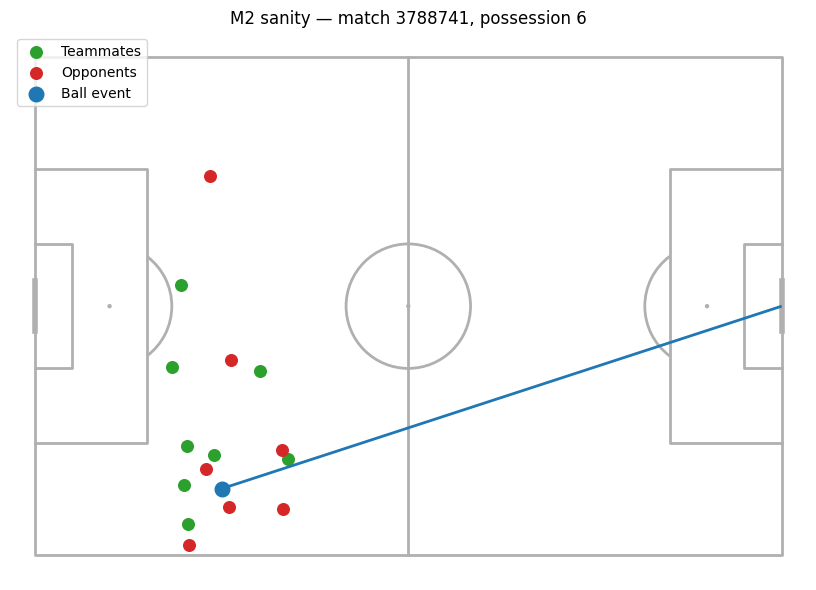

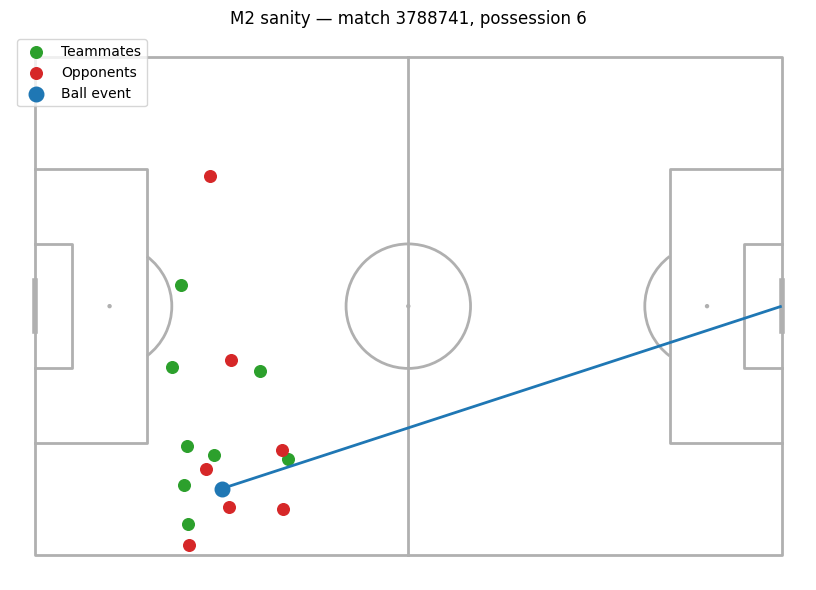

In [9]:
from beyond_the_ball.eval.plots import plot_freeze_frame_event

sample_match_id = loaded["match_id"].dropna().iloc[0]
match_df = loaded[loaded["match_id"] == sample_match_id]

with_frame = match_df[match_df["freeze_frame"].notna() & match_df["location"].notna()]
sample_possession = with_frame["possession"].iloc[0]
possession_df = with_frame[with_frame["possession"] == sample_possession]
print(f"match_id={sample_match_id}, possession={sample_possession}, events={len(possession_df)}")

sample_event = possession_df.iloc[len(possession_df) // 2]
fig, ax = plot_freeze_frame_event(
    canonical_df=loaded,
    event_uuid=sample_event["event_uuid"],
    title=f"M2 sanity — match {sample_match_id}, possession {sample_possession}",
)
fig

In [10]:
def frames_to_df(raw_frames, match_id):
    """One row per event, freeze_frame kept as a list of player dicts."""
    rows = []
    for frame in raw_frames:
        rows.append({
            'match_id': match_id,
            'event_uuid': frame['event_uuid'],
            'visible_area': frame.get('visible_area'),
            'freeze_frame': frame.get('freeze_frame'),
            'n_visible_players': len(frame.get('freeze_frame', [])),
        })
    return pd.DataFrame(rows)

frames_df = frames_to_df(raw_frames, test_match_id)
print(f"Shape: {frames_df.shape}")
print(f"Avg visible players per frame: {frames_df['n_visible_players'].mean():.1f}")
print(f"Min visible: {frames_df['n_visible_players'].min()}, Max: {frames_df['n_visible_players'].max()}")
frames_df.head(3)

Shape: (4220, 5)
Avg visible players per frame: 19.1
Min visible: 7, Max: 22


,match_id,event_uuid,visible_area,freeze_frame,n_visible_players
0,3795108,ea57ee78-a4ef-4d62-81c7-98cdf1c11925,"[120.0, 80.0, 0.0, 80.0, 0.0, 77.9359903100536...","[{'teammate': True, 'actor': False, 'keeper': ...",20
1,3795108,66655fd3-2764-4532-b1bb-0a01074fed30,"[0.0, 80.0, 0.0, 68.3780973203674, 35.45516025...","[{'teammate': True, 'actor': True, 'keeper': F...",20
2,3795108,3765b81d-d184-4aff-a532-e9e11228c561,"[0.0, 80.0, 0.0, 68.3780973203674, 35.45516025...","[{'teammate': True, 'actor': True, 'keeper': F...",20


In [11]:
import time

events_dir = RAW_DIR / "events"
frames_dir = RAW_DIR / "frames"
events_dir.mkdir(exist_ok=True)
frames_dir.mkdir(exist_ok=True)

failed = []
for i, row in matches.iterrows():
    mid = row['match_id']
    events_path = events_dir / f"{mid}.parquet"
    frames_path = frames_dir / f"{mid}.parquet"

    if events_path.exists() and frames_path.exists():
        continue

    try:
        ev = sb.events(match_id=mid)
        ev.to_parquet(events_path)

        fr_dict = sb.frames(match_id=mid, fmt="dict")
        fr = frames_to_df(fr_dict, mid)
        fr.to_parquet(frames_path)

        if i % 10 == 0:
            print(f"[{i+1}/{len(matches)}] match {mid} ok")
    except Exception as e:
        print(f"FAILED match {mid}: {e}")
        failed.append((mid, str(e)))
        time.sleep(1)

print(f"\nDone. Failures: {len(failed)}")
if failed:
    for mid, err in failed:
        print(f"  {mid}: {err}")


Done. Failures: 0


In [12]:
events_files = list(events_dir.glob("*.parquet"))
frames_files = list(frames_dir.glob("*.parquet"))

print(f"Matches with events: {len(events_files)}")
print(f"Matches with 360 frames: {len(frames_files)}")

total_events = 0
total_frames = 0
for f in events_files:
    total_events += len(pd.read_parquet(f))
for f in frames_files:
    total_frames += len(pd.read_parquet(f))

print(f"Total events: {total_events:,}")
print(f"Total 360 frames: {total_frames:,}")
print(f"% events with a 360 frame: {100 * total_frames / total_events:.1f}%")

Matches with events: 102
Matches with 360 frames: 102


Total events: 380,550
Total 360 frames: 330,413
% events with a 360 frame: 86.8%


In [13]:
## M2 check

In [14]:
import pandas as pd

events = pd.read_parquet("../data/interim/events_360_open_play.parquet")
print(f"Shape: {events.shape}")
print(f"Columns: {events.columns.tolist()}")
print(f"\nDtypes:")
print(events.dtypes)
events.head(3)

Shape: (162345, 120)
Columns: ['ball_receipt_outcome', 'ball_recovery_offensive', 'ball_recovery_recovery_failure', 'block_deflection', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_right_foot', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_won_advantage', 'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_punched_out', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'interception_outcome', 'location', 'match_id', 'minute', 'miscontrol_aerial_won', 'off_camera', 'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_deflected', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_inswinging', 'pass_length', 'pass_no_touch', 'pass_outcome', 'pass_o

,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,event_uuid,match_id_360,visible_area,freeze_frame,n_visible_players,clearance_other,foul_committed_penalty,foul_committed_type,foul_won_penalty,injury_stoppage_in_chain,pass_cut_back,shot_aerial_won,block_offensive,dribble_no_touch,foul_committed_offensive,pass_straight,50_50,goalkeeper_success_in_play,pass_miscommunication,bad_behaviour_card,block_save_block,shot_open_goal,goalkeeper_lost_in_play,shot_one_on_one,goalkeeper_shot_saved_to_post,shot_saved_to_post,goalkeeper_shot_saved_off_target,shot_saved_off_target,shot_redirect,shot_follows_dribble,player_off_permanent,goalkeeper_penalty_saved_to_post
0,NaN,None,None,None,None,None,NaN,None,None,None,None,None,NaN,None,NaN,NaN,0.0,None,NaN,None,None,NaN,None,NaN,NaN,None,NaN,NaN,59645e89-9c7f-46f2-b662-332c5b8bba12,1,NaN,None,3788741,0,None,None,None,None,NaN,NaN,NaN,None,None,None,None,NaN,None,NaN,None,NaN,None,NaN,NaN,None,None,NaN,None,NaN,1,Regular Play,NaN,NaN,NaN,1,Turkey,909,None,0,NaN,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4141.0, 'lineup': [{'player': {'...",Turkey,909,00:00:00.000,Starting XI,None,59645e89-9c7f-46f2-b662-332c5b8bba12,NaN,None,None,NaN,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None
1,NaN,None,None,None,None,None,NaN,None,None,None,None,None,NaN,None,NaN,NaN,0.0,None,NaN,None,None,NaN,None,NaN,NaN,None,NaN,NaN,f063a4b6-f5ad-4576-b31d-a8dbe50f693e,2,NaN,None,3788741,0,None,None,None,None,NaN,NaN,NaN,None,None,None,None,NaN,None,NaN,None,NaN,None,NaN,NaN,None,None,NaN,None,NaN,1,Regular Play,NaN,NaN,NaN,1,Turkey,909,None,0,NaN,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 433.0, 'lineup': [{'player': {'i...",Italy,914,00:00:00.000,Starting XI,None,f063a4b6-f5ad-4576-b31d-a8dbe50f693e,NaN,None,None,NaN,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None
2,NaN,None,None,None,None,None,NaN,None,None,None,None,None,NaN,None,NaN,NaN,0.0,None,NaN,None,None,NaN,None,NaN,NaN,None,NaN,NaN,4d9693c5-29bb-4e73-8913-7ee7a4e465fc,3,NaN,None,3788741,0,None,None,None,None,NaN,NaN,NaN,None,None,None,None,NaN,None,NaN,None,NaN,None,NaN,NaN,None,None,NaN,None,NaN,1,Regular Play,NaN,NaN,NaN,1,Turkey,909,[5c53ec59-b0d0-4515-8fee-d973e0037b56],0,NaN,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,Turkey,909,00:00:00.000,Half Start,None,4d9693c5-29bb-4e73-8913-7ee7a4e465fc,NaN,None,None,NaN,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None

In [15]:
match_info = matches[matches['match_id'] == 3788741].iloc[0]
print(f"{match_info['home_team']} vs {match_info['away_team']}")
print(f"Date: {match_info['match_date']}")
print(f"Score: {match_info['home_score']}-{match_info['away_score']}")
print(f"Competition: comp_id={match_info['competition_id']}, season_id={match_info['season_id']}")
if 'competition_stage' in match_info:
    print(f"Stage: {match_info['competition_stage']}")

Turkey vs Italy
Date: 2021-06-11
Score: 0-3
Competition: comp_id=55, season_id=43
Stage: Group Stage


## M3 — Labels

Compute Q1 (possession terminal class) and Q2 (shot-in-next-N) labels from the
canonical table, persist them under `data/processed/`, and log class balance.

In [16]:
from beyond_the_ball.features.labels import build_label_tables

label_tables = build_label_tables(
    canonical_path="../data/interim/events_360_open_play.parquet",
    output_dir="../data/processed",
    min_events=3,
    n=10,
    restrict_to_possession=True,
)
q1 = label_tables["q1"]
q2 = label_tables["q2"]
print(f"Q1 rows (possessions >=3 events): {len(q1):,}")
print(f"Q2 rows (on-ball events):         {len(q2):,}")

Q1 rows (possessions >=3 events): 6,480
Q2 rows (on-ball events):         86,079


In [17]:
print("Q1 class balance:")
print((q1["label"].value_counts(normalize=True) * 100).round(2).to_string())
print()
print("Q1 counts:")
print(q1["label"].value_counts().to_string())

Q1 class balance:
label
final_third    62.85
turnover       24.98
shot           12.16

Q1 counts:
label
final_third    4073
turnover       1619
shot            788


In [18]:
print(f"Q2 positive rate: {q2['label'].mean() * 100:.2f}%")
print()
print("Q2 by event type (size, positive rate):")
by_type = (
    q2.groupby("type")["label"]
    .agg(["size", "mean"])
    .rename(columns={"size": "n", "mean": "positive_rate"})
)
by_type["positive_rate"] = (by_type["positive_rate"] * 100).round(2)
print(by_type.to_string())

Q2 positive rate: 4.76%

Q2 by event type (size, positive rate):
             n  positive_rate
type                         
Carry    39690           5.18
Dribble   1319           9.40
Pass     44219           4.25
Shot       851           4.23
